<a href="https://colab.research.google.com/github/zainabsajid247-collab/Telco-Customer-Churn-Analysis/blob/main/Telco_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import zipfile
zipfile.ZipFile("archive (3).zip", 'r').extractall("data")

In [4]:
import os
os.listdir("data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [5]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df = df.dropna(subset=['TotalCharges'])
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [13]:
df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.722826
                Yes      11.277174
Two year        No       97.151335
                Yes       2.848665
Name: proportion, dtype: float64

In [14]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True) * 100

InternetService  Churn
DSL              No       81.001656
                 Yes      18.998344
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.565789
                 Yes       7.434211
Name: proportion, dtype: float64

In [15]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True) * 100

PaymentMethod              Churn
Bank transfer (automatic)  No       83.268482
                           Yes      16.731518
Credit card (automatic)    No       84.746877
                           Yes      15.253123
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.798005
                           Yes      19.201995
Name: proportion, dtype: float64

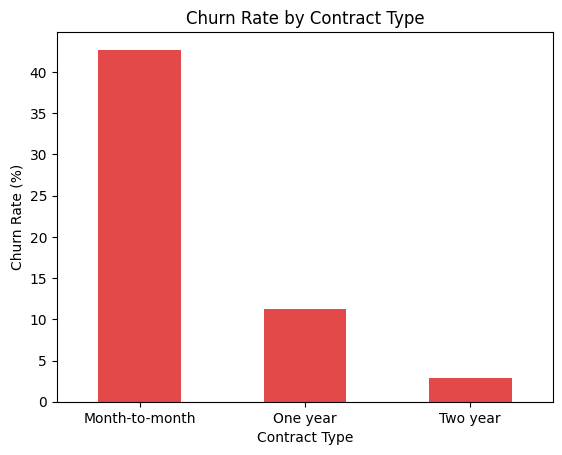

In [16]:
import matplotlib.pyplot as plt

churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_contract['Yes'].plot(kind='bar', color='#e34948')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.show()

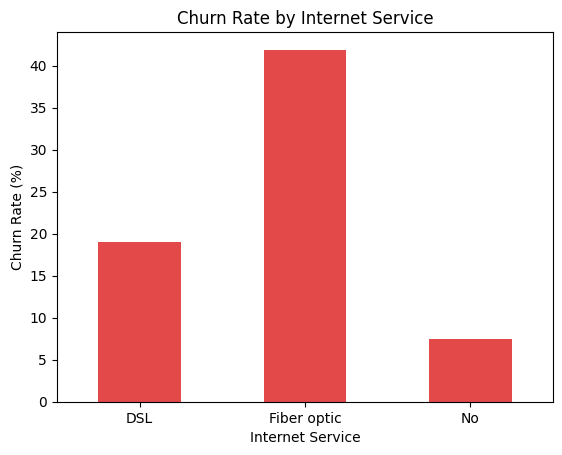

In [17]:
churn_by_internet = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_internet['Yes'].plot(kind='bar', color='#e34948')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Internet Service')
plt.xticks(rotation=0)
plt.show()

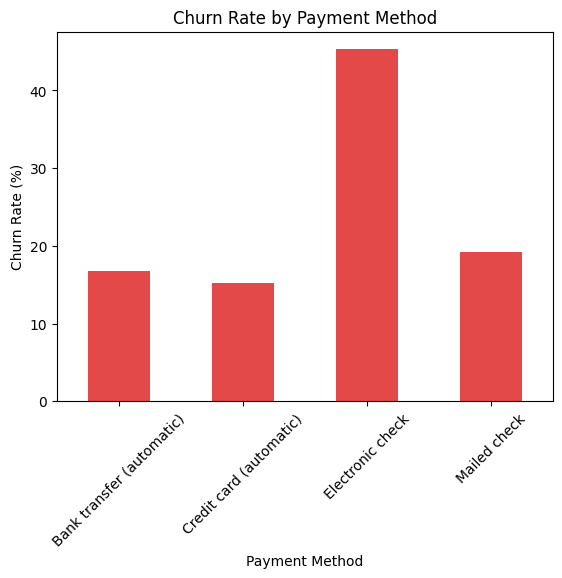

In [18]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_payment['Yes'].plot(kind='bar', color='#e34948')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.show()

In [19]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


## Key Findings & Recommendations

This analysis was conducted on the Telco Customer Churn dataset (7,043 customers). The overall churn rate was 26.6%.

1. **Contract type is the strongest driver of churn.** Month-to-month customers had a churn rate of 42.7%, nearly 15 times higher than two-year contract customers (2.8%). The company should offer discounts or incentives to encourage month-to-month customers to switch to longer-term contracts.

2. **Fiber optic customers show higher dissatisfaction.** Their churn rate (41.9%) is more than double that of DSL customers (19%), which may point to pricing or service quality issues. The company should review Fiber optic pricing and gather customer feedback to identify the root cause.

3. **Electronic check users churn at a much higher rate.** Customers paying via electronic check churned at 45.3%, roughly three times higher than those using automatic payment methods (15–17%). Offering incentives to switch to automatic payments could help reduce churn.

4. **Newer customers are at greater risk of leaving.** Churned customers had an average tenure of just 18 months, compared to 37.6 months for retained customers. The company should implement a targeted retention program for customers in their first year.